# Protocol parameters and a first classic simulation run

Entry point for the `analysis of parameters` folder: documents every constructor parameter of
`sequence_classesV1.Protocol` (and what `ProtocolV2`/`ProtocolV3` override), defines the
`ProfileMLP` model + training utilities used throughout this project, and walks through one
straightforward ("classic") end-to-end simulation:

- Ground truth: the real AAV9 `F_viab`/`J_viab` (from `AAV9_profile_model.ipynb`), used AS IS --
  unlike `analysis of correlation/F_permutation_recovery_correlation.ipynb`, `J_viab` is NOT
  zeroed here; the full Potts model (profile + pairwise) is used.
- `F_sel`/`J_sel` are built from `F_viab`/`J_viab` by permuting the amino-acid axis, using TWO
  INDEPENDENT `jax` keys -- one permutation for `F_sel` (rows of `F_viab`), a DIFFERENT one for
  `J_sel` (both amino-acid axes of `J_viab`). This is deliberately less coherent than
  `initialize_weights.initialize_indep_weights` (which reuses the SAME permutation for both), so
  "amino acid X" in `F_sel` and "amino acid X" in `J_sel` don't necessarily correspond to the
  same relabeling here.
- `ProtocolV3` is instantiated with these weights on a fixed random pool, run for one
  directed-evolution round, and a `ProfileMLP` is trained on the resulting selectivity log
  enrichment (`target2`) -- the same "classic" recipe used throughout `selectivity_weight_regimes/`.


## 0. Setup

In [1]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# Must run before the first `import jax` anywhere -- same convention as the sibling notebooks.


In [2]:
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from flax import nnx
from typing import Optional
import optax
from tqdm.auto import tqdm

from sequence_classesV1 import *
from analysisV1 import *
from initialize_weights import load_F_viab_aav9_mlp, load_J_viab_aav9_mlp, NUM_AMINO_ACIDS, NUM_POSITIONS

print(f"JAX backend: {jax.default_backend()} -- devices: {jax.devices()}")


/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


JAX backend: gpu -- devices: [CudaDevice(id=0)]


## 1. `Protocol` parameters -- what each one controls

`Protocol` (`sequence_classesV1.py`) models one directed-evolution round as a chain of steps --
initial sampling, capsid production (viability), selectivity retention, bacterial amplification
-- with 3 NGS measurement checkpoints along the way (`lambda0p`, `lambda2p`, `lambda3p`).
Grouped by what each parameter feeds into:

**Library / pool**
- `N0` -- total molecule count of the initial library; `lambda0` is set to `N0/d0` uniformly
  across the `d0` sequences.
- `sequences` -- `(d0, 7)` array of amino-acid indices (0..19), the pool of 7-mers being
  tracked. `d0 = sequences.shape[0]` is inferred from it.
- `N1` -- plasmid molecules sampled at the start of each round (`initial_sampling`:
  `lambda1 ~ Poisson(N1 * lambda0/sum(lambda0))`). Module default `10_000_000`.
- `dilution_factor` -- controls pipetting at EVERY NGS checkpoint (`Lambda.sample_sequences`
  draws `Binomial(pool, p=1/dilution_factor)`).
- `D` -- sequencing depth for NGS reads (`Lambda.sequence_reads`); mean read count per
  checkpoint is `D * pool proportions`. Module default `10_000_000_000`.
- `multinomialNGS` -- if `True`, every NGS checkpoint draws `Multinomial(D, proportions)` reads
  instead of the overdispersed Negative Binomial (`phi` unused in that case). Default `False`.
- `phi` -- Negative Binomial dispersion for sequencing reads; smaller = closer to Poisson (less
  overdispersion). Ignored if `multinomialNGS=True`. Module default `0.1`.

**Viability (production) weights & noise**
- `F_viab`, `J_viab` -- `(20, 7)` profile and `(7, 7, 20, 20)` pairwise Potts weights scoring
  viability/production via `compute_score`.
- `noise_viab` -- per-cell expression noise std in `produce_capsids`
  (`E_{s,j} = exp(noise_viab * Z_{s,j})`).
- `alpha` -- capsids produced per transfected HEK cell (Poisson rate scale). Module default `4000`.
- `rho` -- HEK cells transfected per plasmid molecule (`C_s ~ Poisson(rho * lambda1(s))`).
  Module default `1e-3`.
- `T_viab` -- viability temperature: divides the viability score before exponentiating; smaller
  = sharper selection on score, larger = more uniform production. Module default `0.50`.

**Selectivity (retention) weights & noise**
- `F_sel`, `J_sel` -- same shapes as `F_viab`/`J_viab`, score the selectivity/retention step.
- `noise_sel` -- per-sequence noise std added to the selectivity score before retention
  (`noisy_scores = scores + noise_sel * Z`).
- `T_sel` -- selectivity temperature, same role as `T_viab` for the selectivity step. Module
  default `0.50`.

**Amplification (PCR / bacterial growth)**
- `M` -- number of PCR cycles (`Lambda.pcr_amplification`), applied at every NGS checkpoint AND
  (base `Protocol` class only) in `bacterial_amplification`. Module default `40`.
- `K_MM` -- Michaelis-Menten saturation scale for the NGS pipeline's PCR step; should track the
  typical pool size right after pipetting. Module default `1e6`.
- `K_MM_amp` -- Michaelis-Menten saturation scale for the BASE `Protocol.bacterial_amplification`;
  should track `lambda3`'s scale, not `K_MM`. Module default `1e8`. **Unused by `ProtocolV2`/
  `ProtocolV3`** (see class overrides below).

**Defined but unused**
- `epsilon = 0.01` is a module-level constant never referenced anywhere in `Protocol` or
  `Lambda` -- currently dead.

**Class variant overrides (relevant since this notebook uses `ProtocolV3`)**
- `ProtocolBacterialCFU` (parent of `ProtocolV2`) replaces `bacterial_amplification` with a
  deterministic CFU/mass-based model (`CFU_PER_UG=5e9`, `PLASMIDS_PER_UG=1.15e11`,
  `N_DIVISIONS=36`) instead of the base class's Michaelis-Menten PCR-style one -- `K_MM_amp` is
  therefore unused once you're on `ProtocolV2`/`ProtocolV3`.
- `ProtocolV2` replaces `selectivity()` with Binomial retention
  (`lambda3(s) ~ Binomial(lambda2(s), sigmoid(score/T_sel))`, guarantees `lambda3 <= lambda2`).
- `ProtocolV3` (used below) replaces `selectivity()` again with a production-style step
  (`lambda3(s) ~ Poisson(lambda2(s) * exp(noisy_score/T_sel))`), allowing `lambda3(s) >
  lambda2(s)` for well-selected variants -- unlike `ProtocolV2`'s pure filter.

A compact one-row-per-parameter reference table follows for quick lookup.


In [3]:
param_table = pd.DataFrame([
    dict(parameter="N0",              group="library",       default="constructor arg",
         meaning="Total initial-library molecule count; lambda0 = N0/d0 uniformly."),
    dict(parameter="sequences",       group="library",       default="constructor arg",
         meaning="(d0, 7) amino-acid index array -- the tracked pool of 7-mers."),
    dict(parameter="N1",              group="library",       default="10_000_000",
         meaning="Plasmid molecules sampled per round (initial_sampling)."),
    dict(parameter="dilution_factor", group="library",       default="constructor arg",
         meaning="Pipetting dilution at every NGS checkpoint."),
    dict(parameter="D",               group="library",       default="10_000_000_000",
         meaning="Sequencing depth for NGS reads."),
    dict(parameter="multinomialNGS",  group="library",       default="False",
         meaning="Multinomial NGS reads instead of overdispersed Negative Binomial."),
    dict(parameter="phi",             group="library",       default="0.1",
         meaning="NB dispersion for sequencing reads (ignored if multinomialNGS=True)."),
    dict(parameter="F_viab / J_viab", group="viability",     default="constructor arg",
         meaning="(20,7) / (7,7,20,20) Potts weights scoring viability/production."),
    dict(parameter="noise_viab",      group="viability",     default="constructor arg",
         meaning="Per-cell expression noise std in produce_capsids."),
    dict(parameter="alpha",           group="viability",     default="4000",
         meaning="Capsids per transfected HEK cell."),
    dict(parameter="rho",             group="viability",     default="1e-3",
         meaning="HEK cells transfected per plasmid molecule."),
    dict(parameter="T_viab",          group="viability",     default="0.50",
         meaning="Viability temperature (score sharpness)."),
    dict(parameter="F_sel / J_sel",   group="selectivity",   default="constructor arg",
         meaning="Same shapes as F_viab/J_viab, score the retention step."),
    dict(parameter="noise_sel",       group="selectivity",   default="constructor arg",
         meaning="Per-sequence noise std added to the selectivity score."),
    dict(parameter="T_sel",           group="selectivity",   default="0.50",
         meaning="Selectivity temperature (score sharpness)."),
    dict(parameter="M",               group="amplification", default="40",
         meaning="PCR / bacterial-amplification cycles."),
    dict(parameter="K_MM",            group="amplification", default="1e6",
         meaning="Michaelis constant, NGS pipeline PCR step."),
    dict(parameter="K_MM_amp",        group="amplification", default="1e8",
         meaning="Michaelis constant, base Protocol.bacterial_amplification -- UNUSED on ProtocolV2/V3."),
    dict(parameter="epsilon",         group="unused",        default="0.01",
         meaning="Module-level constant, never referenced anywhere -- dead."),
])
param_table


,parameter,group,default,meaning
0,N0,library,constructor arg,Total initial-library molecule count; lambda0 ...
1,sequences,library,constructor arg,"(d0, 7) amino-acid index array -- the tracked ..."
2,N1,library,10_000_000,Plasmid molecules sampled per round (initial_s...
3,dilution_factor,library,constructor arg,Pipetting dilution at every NGS checkpoint.
4,D,library,10_000_000_000,Sequencing depth for NGS reads.
5,multinomialNGS,library,False,Multinomial NGS reads instead of overdispersed...
6,phi,library,0.1,NB dispersion for sequencing reads (ignored if...
7,F_viab / J_viab,viability,constructor arg,"(20,7) / (7,7,20,20) Potts weights scoring via..."
8,noise_viab,viability,constructor arg,Per-cell expression noise std in produce_capsids.
9,alpha,viability,4000,Capsids per transfected HEK cell.


## 2. `ProfileMLP` -- model + training utilities

Same recipe as every `selectivity_weight_regimes` notebook (Linear + BatchNorm + Dropout + gelu,
twice, then a scalar linear head; warmup-cosine-decay AdamW; early stopping on val MSE).


In [4]:
class ProfileMLP(nnx.Module):
    """
    MLP over the one-hot encoded per-position sequence (L=7 positions x A=20 amino acids
    -> 140 indicator features) -> scalar predicted log enrichment.
    """

    def __init__(self, input_dim: int, hidden_dims: tuple[int, int] = (256, 128),
                 dropout_rate: float = 0.1, *, rngs: nnx.Rngs):
        h1, h2 = hidden_dims
        self.linear1    = nnx.Linear(input_dim, h1, rngs=rngs)
        self.batchnorm1 = nnx.BatchNorm(h1, use_running_average=False, rngs=rngs)
        self.dropout1   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear2    = nnx.Linear(h1, h2, rngs=rngs)
        self.batchnorm2 = nnx.BatchNorm(h2, use_running_average=False, rngs=rngs)
        self.dropout2   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear3    = nnx.Linear(h2, 1, rngs=rngs)

    def __call__(self, x: jax.Array, *, train: bool, rngs: Optional[nnx.Rngs] = None) -> jax.Array:
        x = self.linear1(x)
        x = self.batchnorm1(x, use_running_average=not train)
        x = self.dropout1(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        x = self.linear2(x)
        x = self.batchnorm2(x, use_running_average=not train)
        x = self.dropout2(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        return self.linear3(x).squeeze(-1)


In [5]:
@nnx.jit
def train_step(model, optimizer, x, y, rngs):
    def loss_fn(model, rngs):
        y_pred = model(x, train=True, rngs=rngs)
        return jnp.mean((y_pred - y) ** 2)
    loss, grads = nnx.value_and_grad(loss_fn)(model, rngs)
    optimizer.update(model, grads)
    return loss


@nnx.jit
def eval_step(model, x, y):
    y_pred = model(x, train=False)
    return jnp.mean((y_pred - y) ** 2)


@nnx.jit
def predict_log_enrichment(model, x):
    return model(x, train=False)


@nnx.scan(in_axes=(nnx.Carry, 0, 0), out_axes=(nnx.Carry, 0))
def train_epoch_scan(carry, xb, yb):
    model, optimizer, rngs = carry
    loss = train_step(model, optimizer, xb, yb, rngs)
    return (model, optimizer, rngs), loss


In [6]:
def split_train_val(X, y, val_frac=0.15, seed=0):
    rng   = np.random.default_rng(seed)
    idx   = rng.permutation(len(X))
    n_val = int(len(X) * val_frac)
    val_idx, train_idx = idx[:n_val], idx[n_val:]
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]


def train_profile_mlp(X_train, y_train, X_val, y_val, hidden_dims=(128, 64),
                       dropout_rate=0.1, epochs=300, batch_size=256,
                       peak_lr=1e-3, final_lr=1e-5, weight_decay=0,
                       patience=20, seed=0, verbose=True):
    rngs  = nnx.Rngs(seed)
    model = ProfileMLP(input_dim=X_train.shape[1], hidden_dims=hidden_dims,
                        dropout_rate=dropout_rate, rngs=rngs)

    n_train         = X_train.shape[0]
    steps_per_epoch = max(n_train // batch_size, 1)
    total_steps     = steps_per_epoch * epochs

    lr_schedule_fn = optax.warmup_cosine_decay_schedule(
        init_value=0., peak_value=peak_lr,
        warmup_steps=int(total_steps * 0.1),
        decay_steps=int(total_steps * 0.9),
        end_value=final_lr,
    )
    optimizer = nnx.Optimizer(
        model, optax.adamw(learning_rate=lr_schedule_fn, weight_decay=weight_decay), wrt=nnx.Param
    )

    X_train, y_train = jnp.asarray(X_train), jnp.asarray(y_train)
    X_val,   y_val   = jnp.asarray(X_val),   jnp.asarray(y_val)

    shuffle_key = jax.random.key(seed)
    best_val, best_state, bad_epochs = float("inf"), None, 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in tqdm(range(epochs), desc="Training ProfileMLP", disable=not verbose):
        shuffle_key, perm_key = jax.random.split(shuffle_key)
        perm      = jax.random.permutation(perm_key, n_train)
        batch_idx = perm[: steps_per_epoch * batch_size].reshape(steps_per_epoch, batch_size)

        (model, optimizer, rngs), step_losses = train_epoch_scan(
            (model, optimizer, rngs), X_train[batch_idx], y_train[batch_idx]
        )
        train_loss = float(jnp.mean(step_losses))
        val_loss   = float(eval_step(model, X_val, y_val))

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val - 1e-5:
            best_val, bad_epochs = val_loss, 0
            best_state = nnx.state(model)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch} (best val MSE={best_val:.4f})")
                break

    nnx.update(model, best_state)
    return model, history


## 3. Ground truth weights: real AAV9 `F_viab` / `J_viab`

Loaded via `load_F_viab_aav9_mlp` / `load_J_viab_aav9_mlp` -- the real AAV9 profile AND pairwise
coupling, exported by `AAV9_profile_model.ipynb`. Both are used as-is here (no zeroing): this
notebook's baseline run uses the full Potts model.


F_viab shape: (20, 7)   J_viab shape: (7, 7, 20, 20)


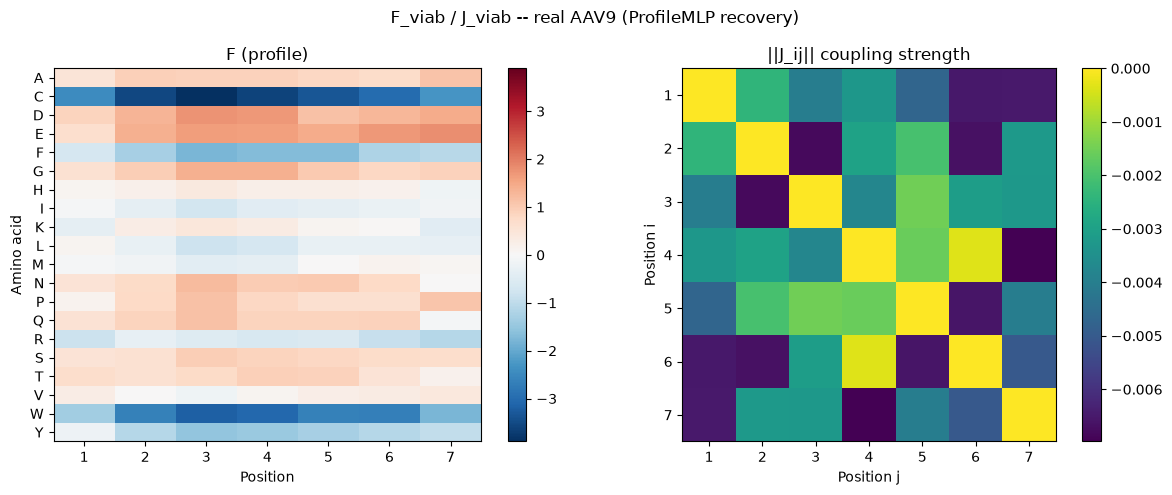

In [7]:
F_viab = load_F_viab_aav9_mlp()
J_viab = load_J_viab_aav9_mlp()

print(f"F_viab shape: {F_viab.shape}   J_viab shape: {J_viab.shape}")
_ = plot_teacher_weights(F_viab, J_viab, title="F_viab / J_viab -- real AAV9 (ProfileMLP recovery)")
plt.show()


## 4. `F_sel` / `J_sel`: two INDEPENDENT permutations of the AAV9 matrices

`F_sel = F_viab[sigma_F, :]` for a random permutation `sigma_F` of the 20 amino acids (key
`key_F`). `J_sel` is built the same way but with a SEPARATE key `key_J`: both of `J_viab`'s
amino-acid axes are permuted by the same `sigma_J`, so `J_sel` stays internally consistent
(`J_sel[i, j, a, b]` and `J_sel[j, i, b, a]` still refer to the same relabeled amino acid pair),
but `sigma_J != sigma_F` in general -- so "amino acid X" in `F_sel` and "amino acid X" in `J_sel`
don't necessarily correspond to the same original AAV9 amino acid. No added noise, same pure
row-permutation mechanic as `analysis of correlation/F_permutation_recovery_correlation.ipynb`.


In [8]:
key_F, key_J = jax.random.split(jax.random.key(0), 2)

sigma_F = jax.random.permutation(key_F, NUM_AMINO_ACIDS)
F_sel   = F_viab[sigma_F, :]

sigma_J = jax.random.permutation(key_J, NUM_AMINO_ACIDS)
J_sel   = J_viab[:, :, sigma_J, :][:, :, :, sigma_J]

print(f"sigma_F (F_sel's amino-acid relabeling): {np.asarray(sigma_F)}")
print(f"sigma_J (J_sel's amino-acid relabeling): {np.asarray(sigma_J)}")


sigma_F (F_sel's amino-acid relabeling): [16 10  0  8  2 11  4  1  7 19 13 17 14 15  9  5 18  3  6 12]
sigma_J (J_sel's amino-acid relabeling): [ 0  3  9  5 18 14  1  8 17  4 13  6  2 19 15 11 10 16 12  7]


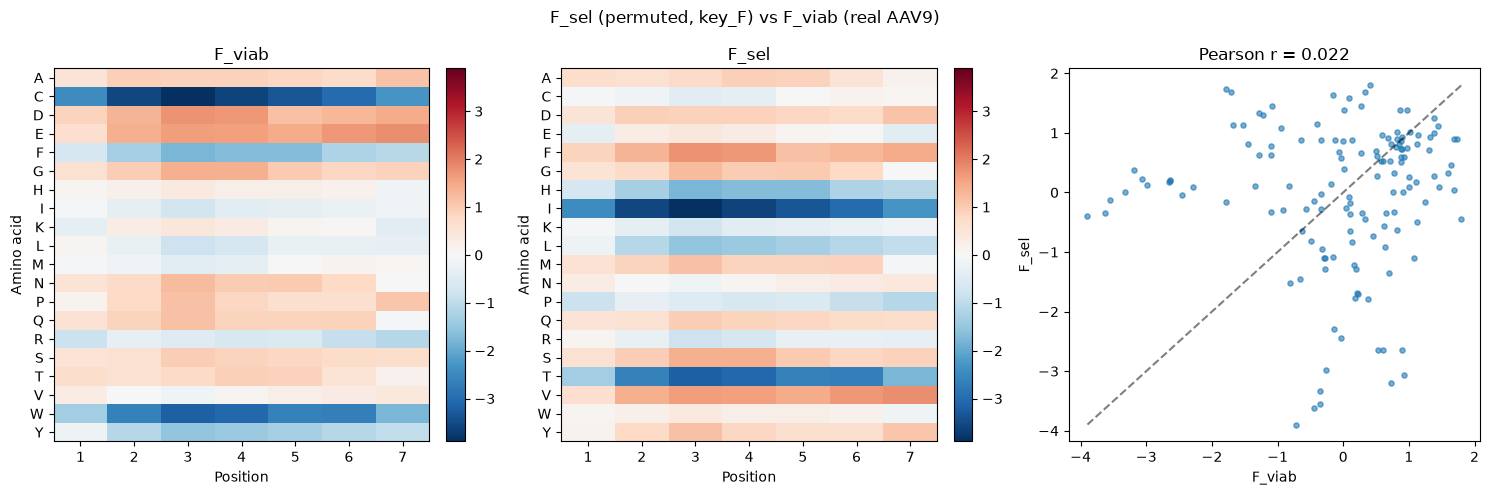

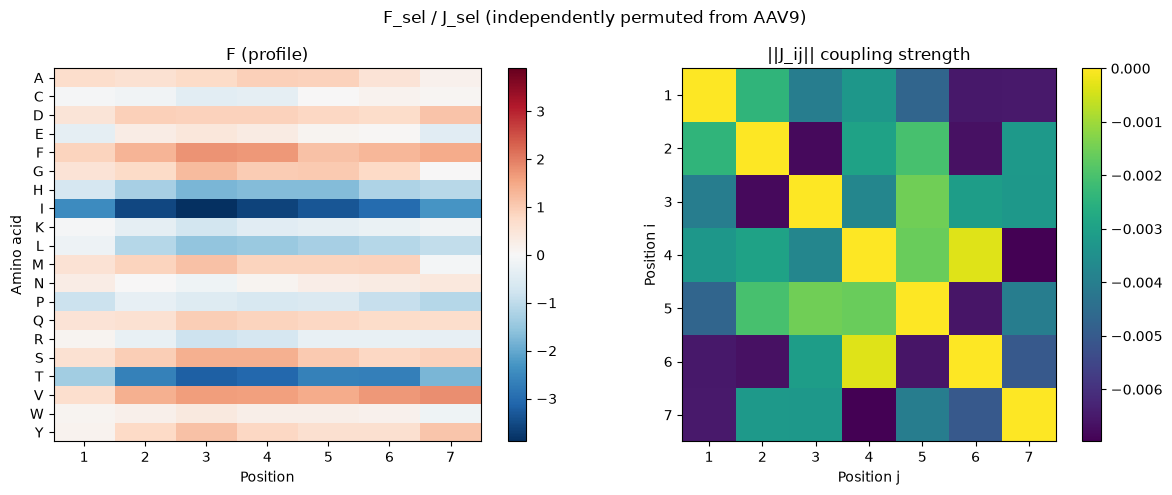

In [9]:
def compare_F(F_a, F_b, title, label_a="F_viab", label_b="F_sel"):
    """Same 3-panel recipe as the sibling notebooks: two heatmaps (shared RdBu_r scale) + a
    raw-entry scatter with Pearson r."""
    F_a, F_b = np.asarray(F_a), np.asarray(F_b)
    vmax = max(np.abs(F_a).max(), np.abs(F_b).max())

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, F, panel_title in [(axes[0], F_a, label_a), (axes[1], F_b, label_b)]:
        im = ax.imshow(F, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        ax.set_title(panel_title)
        ax.set_xlabel("Position"); ax.set_ylabel("Amino acid")
        ax.set_xticks(range(NUM_POSITIONS)); ax.set_xticklabels(range(1, NUM_POSITIONS + 1))
        ax.set_yticks(range(NUM_AMINO_ACIDS)); ax.set_yticklabels(AA_LABELS)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    r = pearson(F_a.ravel(), F_b.ravel())
    axes[2].scatter(F_a.ravel(), F_b.ravel(), s=14, alpha=0.6)
    lims = [min(F_a.min(), F_b.min()), max(F_a.max(), F_b.max())]
    axes[2].plot(lims, lims, "k--", alpha=0.5)
    axes[2].set_xlabel(label_a); axes[2].set_ylabel(label_b)
    axes[2].set_title(f"Pearson r = {r:.3f}")

    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


compare_F(F_viab, F_sel, "F_sel (permuted, key_F) vs F_viab (real AAV9)",
          label_a="F_viab", label_b="F_sel")
_ = plot_teacher_weights(F_sel, J_sel, title="F_sel / J_sel (independently permuted from AAV9)")
plt.show()


In [10]:
off_diag = ~np.eye(NUM_POSITIONS, dtype=bool)
r_F = pearson(np.asarray(F_viab).ravel(), np.asarray(F_sel).ravel())
r_J = pearson(np.asarray(J_viab)[off_diag].ravel(), np.asarray(J_sel)[off_diag].ravel())

print(f"Pearson r(F_sel, F_viab)                    = {r_F:+.4f}")
print(f"Pearson r(J_sel, J_viab)  (off-diagonal only) = {r_J:+.4f}")


Pearson r(F_sel, F_viab)                    = +0.0216
Pearson r(J_sel, J_viab)  (off-diagonal only) = -0.0302


## 5. First classic use: run `ProtocolV3` end-to-end on a fixed pool

Same reference parameters used throughout `selectivity_weight_regimes/` (`N0=1e9`, `N1=5e8`,
`dilution_factor=10`, `D=1e9`, `noise_viab=noise_sel=0.5`, `T_sel=T_viab=1`) -- a fixed pool of
`N=20,000` random 7-mers, one directed-evolution round via `N_loop_DE(1)`.


In [16]:
key_pool  = jax.random.key(1)
N = 20_000
sequences = jax.random.randint(key_pool, shape=(N, NUM_POSITIONS), minval=0, maxval=NUM_AMINO_ACIDS)

protocol = ProtocolV3(N0=1_000_000_000, N1=500_000_000,
        dilution_factor=10, sequences=sequences, D=1e9,
        F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
        noise_viab=0.5, noise_sel=0.5, multinomialNGS=True, T_sel=1, T_viab=1,
        )

print(f"sequences: {N:,}   d0={protocol.d0}")


sequences: 20,000   d0=20000


In [17]:
def lambda_evolution_table(protocol, n_rounds=1):
    """
    Runs protocol.N_loop_DE(n_rounds) and tabulates total abundance + surviving diversity for
    every lambda checkpoint, in true pipeline order, one column group per round.
    """
    rounds = protocol.N_loop_DE(n_rounds)
    stages = ["lambda0", "lambda0p", "lambda1", "lambda2", "lambda2p", "lambda3", "lambda3p", "lambda4"]

    rows = []
    for round_idx, (bio_row, ngs_row) in enumerate(rounds):
        lambda0, lambda1, lambda2, lambda3, lambda4 = bio_row
        lambda0p, lambda2p, lambda3p = ngs_row
        stage_arrays = {
            "lambda0": lambda0, "lambda0p": lambda0p, "lambda1": lambda1,
            "lambda2": lambda2, "lambda2p": lambda2p, "lambda3": lambda3,
            "lambda3p": lambda3p, "lambda4": lambda4,
        }
        for stage in stages:
            arr = np.asarray(stage_arrays[stage])
            rows.append(dict(
                round=round_idx, stage=stage,
                total=float(arr.sum()), n_surviving=int((arr > 0).sum()),
            ))

    df = pd.DataFrame(rows)
    df["pct_surviving"] = 100 * df["n_surviving"] / protocol.d0
    return df.pivot(index="stage", columns="round", values=["total", "n_surviving", "pct_surviving"]).reindex(stages)

lambda_evolution_table(protocol, n_rounds=1)


Directed evolution rounds: 100%|██████████| 1/1 [00:07<00:00,  7.62s/it]


,total,n_surviving,pct_surviving
round,0,0,0
stage,,,
lambda0,9.000123e+08,20000.0,100.000
lambda0p,9.999890e+08,20000.0,100.000
lambda1,4.999774e+08,20000.0,100.000
lambda2,6.132931e+10,19999.0,99.995
lambda2p,9.999982e+08,19804.0,99.020
lambda3,7.804978e+11,19792.0,98.960
lambda3p,1.000009e+09,16356.0,81.780
lambda4,9.999743e+08,16384.0,81.920


**Gotcha worth knowing about `N_loop_DE`**: its last line before returning is
`self.lambda0 = self.lambda4` -- it re-seeds `lambda0` from `lambda4` so a FOLLOW-UP call can
start its own round from where this one left off. That reassignment runs even after the FINAL
requested round, though, so right after `protocol.N_loop_DE(1)` returns, `protocol.lambda0` is
actually this round's `lambda4` (the post-selectivity, post-amplification pool), not this
round's own (pre-viability, still-nearly-uniform) `lambda0`. Reading `protocol.lambda0` at that
point would show a strong score-dependent gradient that has nothing to do with `lambda0` itself
-- it's `lambda4` mislabeled. The cell below restores `protocol.lambda0` to the correct value
(from the unpacked `bio_row`) before calling `plot_all_lambda_scores`, which reads the LIVE
`protocol.lambda0` attribute.


Directed evolution rounds: 100%|██████████| 1/1 [00:07<00:00,  7.39s/it]


log_enr_viab: min=-10.86  max=4.55  mean=-3.78
log_enr_sel : min=-13.07  max=8.49  mean=-2.41


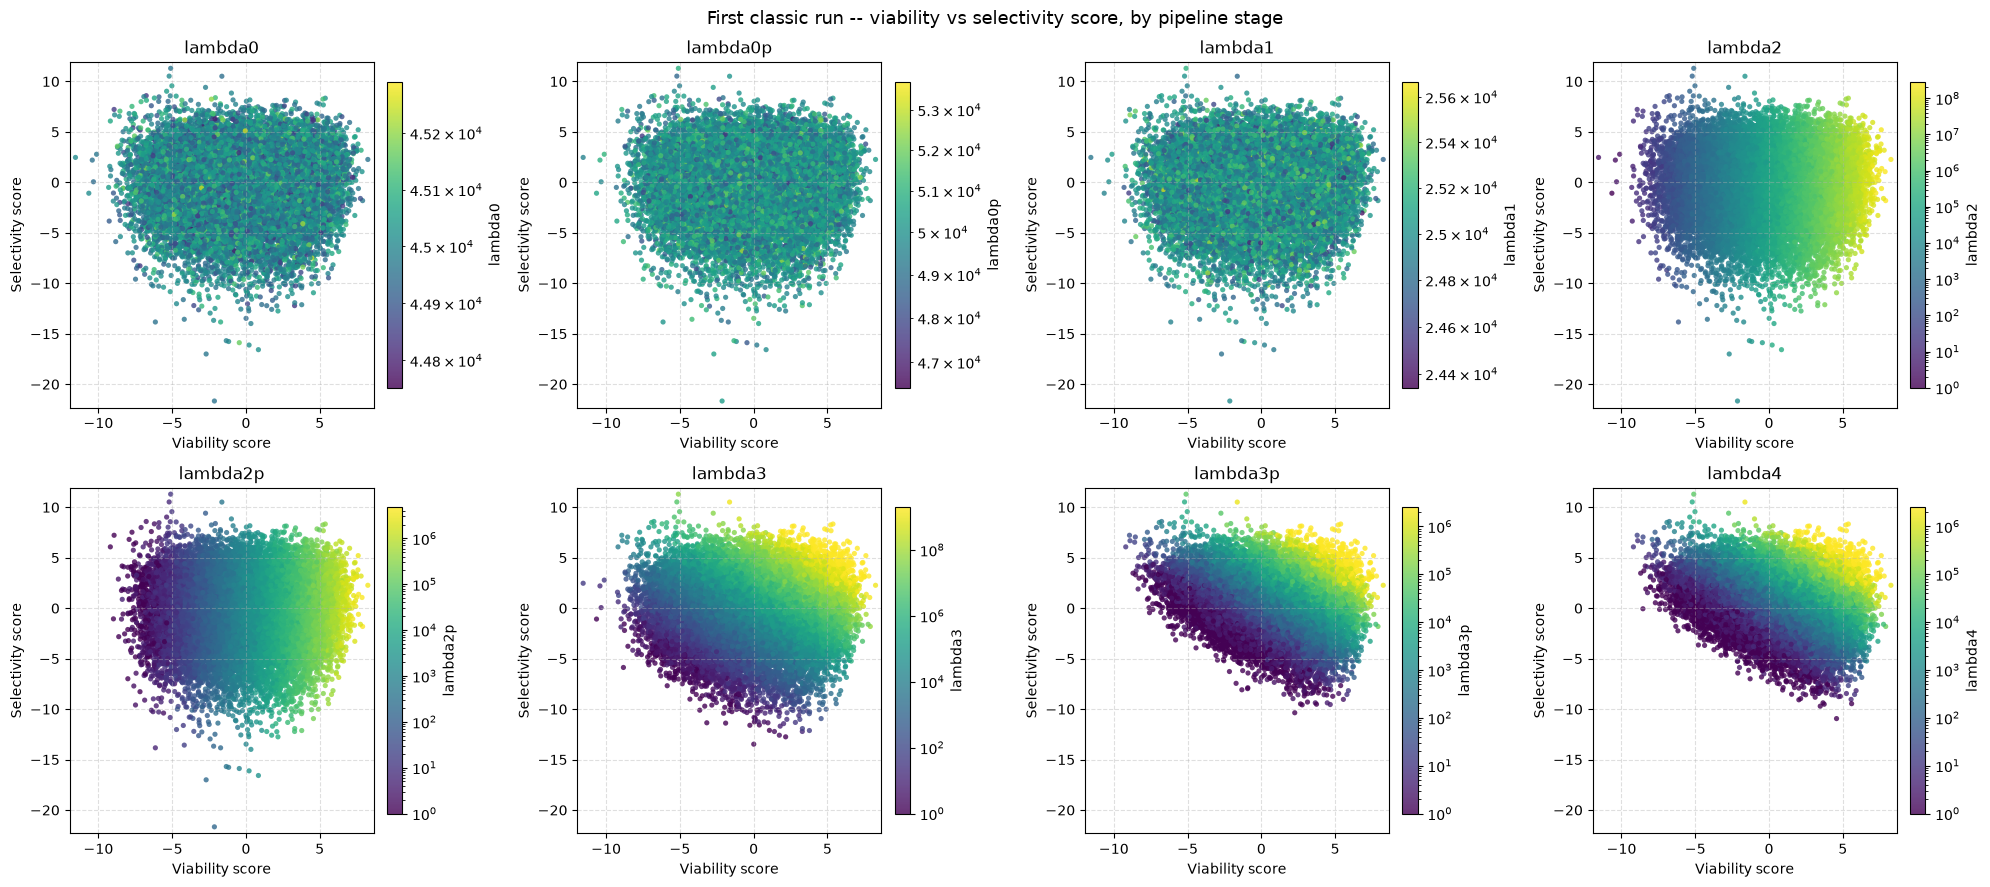

In [18]:
rounds = protocol.N_loop_DE(1)
bio_row, ngs_row = rounds[0]
lambda0, lambda1, lambda2, lambda3, lambda4 = bio_row
lambda0p, lambda2p, lambda3p               = (np.asarray(a) for a in ngs_row)

# N_loop_DE's last line (`self.lambda0 = self.lambda4`) re-seeds lambda0 for a HYPOTHETICAL
# next round -- it runs even after the FINAL requested round, so protocol.lambda0 is now
# aliased to THIS round's lambda4, not this round's own (still-nearly-uniform) lambda0. Restore
# it before plotting, or plot_all_lambda_scores below would show lambda4 mislabeled as lambda0
# (a strong score-dependent gradient where there should be none -- lambda0 is pre-viability).
protocol.lambda0 = lambda0

eps = 1.0  # pseudocount of 1 read -- same convention as the sibling notebooks
log_enr_viab = np.log((lambda2p + eps) / (lambda0p + eps))  # target1 -- viability phase, NGS-measured
log_enr_sel  = np.log((lambda3p + eps) / (lambda2p + eps))  # target2 -- selectivity phase, NGS-measured

print(f"log_enr_viab: min={log_enr_viab.min():.2f}  max={log_enr_viab.max():.2f}  mean={log_enr_viab.mean():.2f}")
print(f"log_enr_sel : min={log_enr_sel.min():.2f}  max={log_enr_sel.max():.2f}  mean={log_enr_sel.mean():.2f}")

_ = plot_all_lambda_scores(protocol, title="First classic run -- viability vs selectivity score, by pipeline stage")
plt.show()


## 7. Next steps

This notebook is the reference baseline for the `analysis of parameters` folder: same `ProtocolV3`
instantiation, same fixed pool, same `ProfileMLP` recipe as every other notebook in this project,
now with the parameter table above as a standing reference. Natural follow-ups from here, each
varying ONE parameter at a time from this baseline (same convention as
`MLP_viability_noise_denoising20K.ipynb`'s `noise_viab` sweep):

- `N1` / `dilution_factor` / `rho` -- how harsh the population bottleneck is (fewer surviving
  variants per round), independent of `T_viab`/`T_sel`.
- `T_viab` / `T_sel` -- how sharply score differences translate into abundance differences.
- `noise_viab` / `noise_sel` -- denoising capacity of the MLP (see the noise-sweep notebook for
  the viability-only version of this question).
- `M` / `K_MM` -- PCR/amplification saturation dynamics at the NGS checkpoints.
